# Field Line Geometry with Mageometry

Frenet-Serret frame, curvature, torsion, and the nine directional derivative formulas — the core of the Mageometry analysis library.

Every geometry function in Mageometry takes the magnetic field as a plain callable `field(x, y, z) -> (bx, by, bz)`. This notebook uses the geopack Tsyganenko models as the field source (via `geopack_field`); the identical calls work on simulation data (see notebook 08).

## Contents

1. [Setup: a field callable](#setup)
2. [Mathematical background](#background)
3. [The Frenet-Serret frame at a point](#frame)
4. [The nine directional derivative formulas](#derivatives)
5. [Validity, NaN, and the finite-difference quality diagnostic](#validity)
6. [Choosing the step size δ](#delta)
7. [Geometry along a traced field line](#trace)
8. [Vectorization: looped vs batched evaluation](#performance)
9. [Maps in the noon-midnight meridian](#maps)
10. [Limitations and best practices](#limitations)

In [1]:
import time
from datetime import datetime, timezone

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (3D projection)

from mageometry import (
    geopack,
    geopack_field,
    trace_field_lines,
    field_line_curvature,
    field_line_torsion,
    field_line_frenet_frame,
    field_line_geometry_complete,
    field_line_frame_quality,
    field_line_directional_derivatives,
    verify_antisymmetry_relations,
    get_curvature_torsion_from_derivatives,
    verify_unit_vectors,
)

%matplotlib inline

Load IGRF coefficients ...


<a id="setup"></a>
## 1. Setup: a field callable

`geopack_field(external, internal, parmod, ps)` binds the model parameters and returns a callable that evaluates the total field (internal + external) at arbitrary GSM positions (Re in, nT out). `geopack.recalc(ut)` must be called first: it sets the epoch of the internal field and returns the dipole tilt angle `ps`.

In [2]:
ut = datetime(2023, 3, 15, 12, 0, 0, tzinfo=timezone.utc).timestamp()
ps = geopack.recalc(ut)

# T96 parameters: [Pdyn (nPa), Dst (nT), ByIMF (nT), BzIMF (nT), 0, 0, 0, 0, 0, 0]
parmod = [2.0, -20.0, 0.0, -5.0, 0, 0, 0, 0, 0, 0]

field = geopack_field("t96", "dip", parmod, ps)    # total field: T96 + dipole
dipole = geopack_field(None, "dip")                # pure (tilted) dipole, for analytic checks

print(f"Dipole tilt: {np.degrees(ps):.2f} deg")
print("B at (-5, 0, 0) Re [nT]:", field(-5.0, 0.0, 0.0))

Dipole tilt: 0.29 deg
B at (-5, 0, 0) Re [nT]: (np.float64(-3.329155611442921), np.float64(2.0560327983219063e-16), np.float64(165.45711161337368))


<a id="background"></a>
## 2. Mathematical background

A magnetic field line is a space curve tangent to **B**. Its Frenet-Serret frame consists of three orthonormal vectors:

- **T** = **B**/|**B**|, the unit tangent,
- **n** = (d**T**/ds)/|d**T**/ds|, the principal normal (toward the center of curvature),
- **b** = **T** × **n**, the binormal,

with the Frenet-Serret formulas (s = arc length)

$$\frac{d\mathbf{T}}{ds} = \kappa\,\mathbf{n},\qquad \frac{d\mathbf{n}}{ds} = -\kappa\,\mathbf{T} + \tau\,\mathbf{b},\qquad \frac{d\mathbf{b}}{ds} = -\tau\,\mathbf{n}.$$

κ is the curvature (1/Re) and τ the torsion (1/Re).

Mageometry evaluates d/ds by central finite differences along the local tangent: d**T**/ds ≈ [**T**(r + δ**T**) − **T**(r − δ**T**)]/2δ. The normal is taken as the component of that estimate perpendicular to **T** (the parallel component is pure truncation error), so the returned frame is orthonormal by construction.

### The nine directional derivative formulas

Beyond derivatives *along* the line, the frame can be differentiated along **n** and **b** as well. For unit vectors, (∂**v**/∂**u**)·**v** = 0, and orthonormality gives the antisymmetry (∂**v**/∂**u**)·**w** = −(∂**w**/∂**u**)·**v**. Nine independent projections remain:

| key | formula | meaning |
|---|---|---|
| `dT_dT_n` | (∂T/∂T)·n | κ, curvature |
| `dT_dT_b` | (∂T/∂T)·b | 0 (identity) |
| `dn_dT_b` | (∂n/∂T)·b | τ, torsion |
| `dT_dn_n` | (∂T/∂n)·n | normal curvature |
| `dT_dn_b` | (∂T/∂n)·b | |
| `dn_dn_b` | (∂n/∂n)·b | |
| `dn_db_b` | (∂n/∂b)·b | |
| `dn_db_T` | (∂n/∂b)·T | |
| `db_db_T` | (∂b/∂b)·T | |

`field_line_directional_derivatives` returns these nine plus their antisymmetric partners (e.g. `dn_dT_T` = −κ), so `verify_antisymmetry_relations` can check the numerics.

<a id="frame"></a>
## 3. The Frenet-Serret frame at a point

`field_line_geometry_complete` returns the frame, curvature, and torsion in one call. Functions accept scalars (returning floats) or arrays (returning arrays).

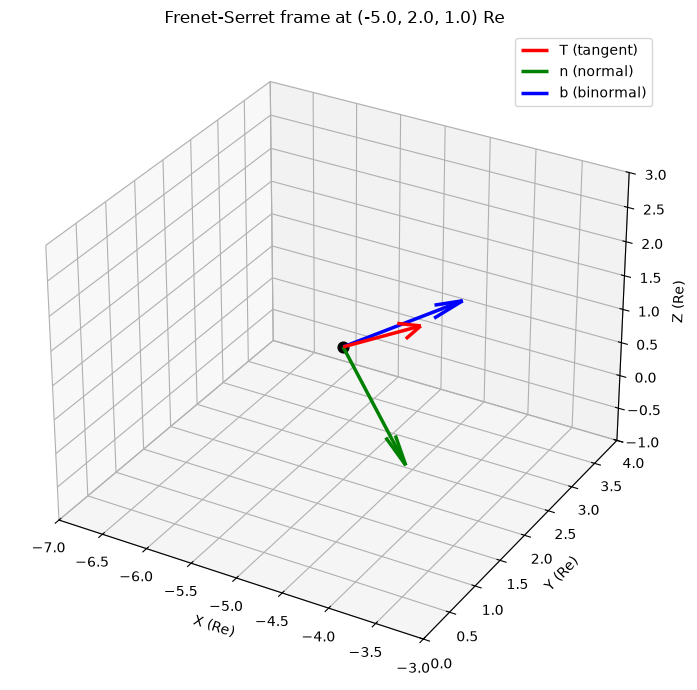

curvature kappa = 0.35212 1/Re   (radius of curvature 2.840 Re)
torsion   tau   = -0.02815 1/Re

Orthonormality (all should be ~1e-16):
  |T| - 1  2.2e-16
  |n| - 1  1.1e-16
  |b| - 1  3.3e-16
  T·n      0.0e+00
  T·b      1.2e-17
  n·b      5.2e-18
  b - T×n  0.0e+00


In [3]:
x0, y0, z0 = -5.0, 2.0, 1.0
tx, ty, tz, nx, ny, nz, bx, by, bz, kappa, tau = field_line_geometry_complete(field, x0, y0, z0, delta=0.01)

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter([x0], [y0], [z0], c="k", s=60)
for vec, color, label in [((tx, ty, tz), "red", "T (tangent)"),
                          ((nx, ny, nz), "green", "n (normal)"),
                          ((bx, by, bz), "blue", "b (binormal)")]:
    ax.quiver(x0, y0, z0, *vec, length=1.5, color=color, arrow_length_ratio=0.25, linewidth=2.5, label=label)
ax.set_xlim(x0 - 2, x0 + 2); ax.set_ylim(y0 - 2, y0 + 2); ax.set_zlim(z0 - 2, z0 + 2)
ax.set_xlabel("X (Re)"); ax.set_ylabel("Y (Re)"); ax.set_zlabel("Z (Re)")
ax.set_title(f"Frenet-Serret frame at ({x0}, {y0}, {z0}) Re")
ax.legend()
plt.tight_layout()
plt.show()

print(f"curvature kappa = {kappa:.5f} 1/Re   (radius of curvature {1/kappa:.3f} Re)")
print(f"torsion   tau   = {tau:.5f} 1/Re")
print("\nOrthonormality (all should be ~1e-16):")
for name, err in verify_unit_vectors(tx, ty, tz, nx, ny, nz, bx, by, bz).items():
    print(f"  {name:8s} {abs(err):.1e}")

<a id="derivatives"></a>
## 4. The nine directional derivative formulas

At a single point the function returns a dict of floats; the curvature and torsion it contains agree with the dedicated `field_line_curvature` / `field_line_torsion` functions.

In [4]:
x, y, z = -5.0, 0.0, 0.0
delta = 0.01
d = field_line_directional_derivatives(field, x, y, z, delta=delta)

print(f"Directional derivatives at ({x}, {y}, {z}) Re [1/Re]")
print("-" * 44)
for key, label in [("dT_dT_n", "(dT/dT).n = kappa"), ("dT_dT_b", "(dT/dT).b = 0"), ("dn_dT_b", "(dn/dT).b = tau"),
                   ("dT_dn_n", "(dT/dn).n"), ("dT_dn_b", "(dT/dn).b"), ("dn_dn_b", "(dn/dn).b"),
                   ("dn_db_b", "(dn/db).b"), ("dn_db_T", "(dn/db).T"), ("db_db_T", "(db/db).T")]:
    print(f"  {label:20s} {d[key]: .6f}")

k_d, t_d = get_curvature_torsion_from_derivatives(d)
print("\nConsistency with the geometry functions:")
print(f"  kappa: derivatives {k_d:.6f}  vs  field_line_curvature {field_line_curvature(field, x, y, z, delta=delta):.6f}")
print(f"  tau:   derivatives {t_d:.6f}  vs  field_line_torsion   {field_line_torsion(field, x, y, z, delta=delta):.6f}")

Directional derivatives at (-5.0, 0.0, 0.0) Re [1/Re]
--------------------------------------------
  (dT/dT).n = kappa     1.006921
  (dT/dT).b = 0         0.000000
  (dn/dT).b = tau      -0.000000
  (dT/dn).n             0.029410
  (dT/dn).b            -0.000000
  (dn/dn).b            -0.000000
  (dn/db).b            -0.191529
  (dn/db).T             0.000000
  (db/db).T            -0.004918

Consistency with the geometry functions:
  kappa: derivatives 1.006921  vs  field_line_curvature 1.006921
  tau:   derivatives -0.000000  vs  field_line_torsion   -0.000000


With array input, all nine quantities come back as arrays. Here they are along the midnight meridian in the equatorial plane; the antisymmetry relations hold to finite-difference accuracy.

Antisymmetry relations (max |error|):
  κ_check          2.22e-15
  τ_check          3.12e-21
  zero_check_1     2.78e-23
  dT_dn_n_check    1.55e-15
  dT_dn_b_check    9.50e-23
  dn_dn_b_check    7.93e-23
  dn_db_b_check    2.04e-09
  dn_db_T_check    2.07e-15
  db_db_T_check    2.31e-08


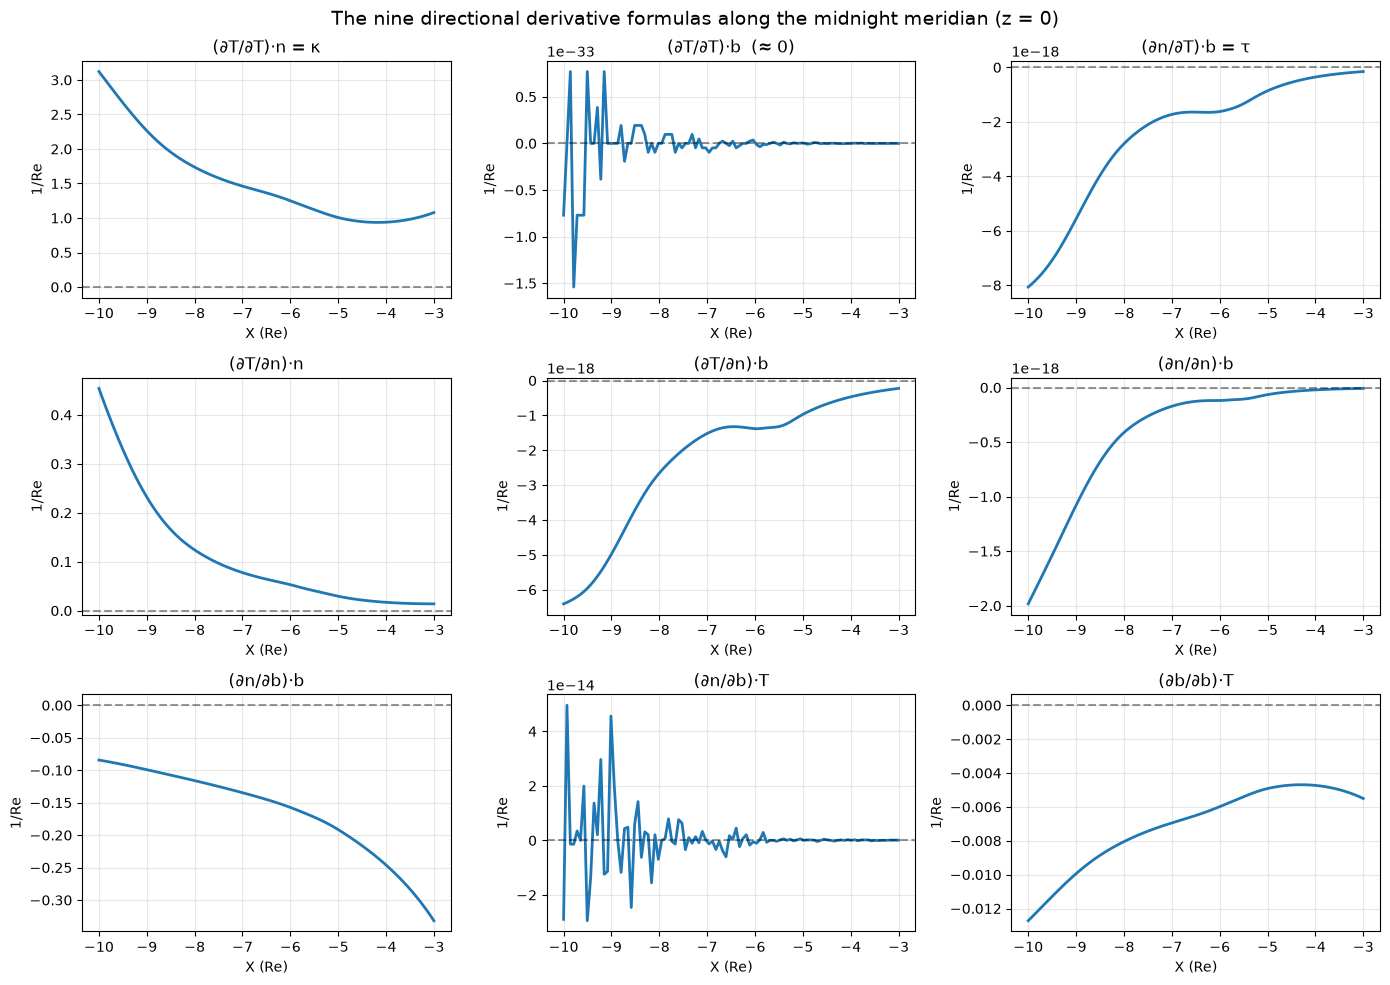

In [5]:
x_arr = np.linspace(-10, -3, 100)
y_arr = np.zeros_like(x_arr)
z_arr = np.zeros_like(x_arr)
d_arr = field_line_directional_derivatives(field, x_arr, y_arr, z_arr, delta=delta)

print("Antisymmetry relations (max |error|):")
for name, err in verify_antisymmetry_relations(d_arr).items():
    print(f"  {name:16s} {np.nanmax(np.abs(err)):.2e}")

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
fig.suptitle("The nine directional derivative formulas along the midnight meridian (z = 0)", fontsize=14)
panels = [("dT_dT_n", "(∂T/∂T)·n = κ"), ("dT_dT_b", "(∂T/∂T)·b  (≈ 0)"), ("dn_dT_b", "(∂n/∂T)·b = τ"),
          ("dT_dn_n", "(∂T/∂n)·n"), ("dT_dn_b", "(∂T/∂n)·b"), ("dn_dn_b", "(∂n/∂n)·b"),
          ("dn_db_b", "(∂n/∂b)·b"), ("dn_db_T", "(∂n/∂b)·T"), ("db_db_T", "(∂b/∂b)·T")]
for ax, (key, label) in zip(axes.ravel(), panels):
    ax.plot(x_arr, d_arr[key], lw=2)
    ax.axhline(0, color="k", ls="--", alpha=0.4)
    ax.set_title(label); ax.set_xlabel("X (Re)"); ax.set_ylabel("1/Re"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<a id="validity"></a>
## 5. Validity, NaN, and the finite-difference quality diagnostic

Quantities that are undefined or numerically unreliable are returned as **NaN** — never as a zero sentinel — so one `np.isfinite` mask handles every case:

- the tangent where |**B**| is zero or non-finite (magnetic nulls, points outside a simulation grid);
- the normal and binormal (and everything built on them) where the curvature vanishes, i.e. on straight field lines;
- the normal and binormal where the finite difference does not resolve the curvature.

The last case is decided by the diagnostic `cos θ = |T·dT/ds| / |dT/ds|`, available as `field_line_frame_quality`. For an exact derivative it is zero; for the central difference it grows as δ²|κ'|/(3κ), i.e. where the curvature changes rapidly compared with δ. Frames with cos θ above `orthogonality_tol` (default 0.1) are reported as NaN — a cue to reduce δ rather than a silent zero.

uniform field: kappa = 0.0  normal = (nan, nan, nan)
X-null at origin: tangent = (nan, nan, nan)
delta=0.01   median cos(theta) = 1.6e-06   max = 7.1e-05   fraction > tol(0.1): 0.000
delta=0.05   median cos(theta) = 4.1e-05   max = 1.8e-03   fraction > tol(0.1): 0.000


delta=0.1    median cos(theta) = 1.6e-04   max = 7.0e-03   fraction > tol(0.1): 0.000
delta=0.25   median cos(theta) = 1.0e-03   max = 3.9e-02   fraction > tol(0.1): 0.000
delta=0.5    median cos(theta) = 4.0e-03   max = 1.4e-01   fraction > tol(0.1): 0.001


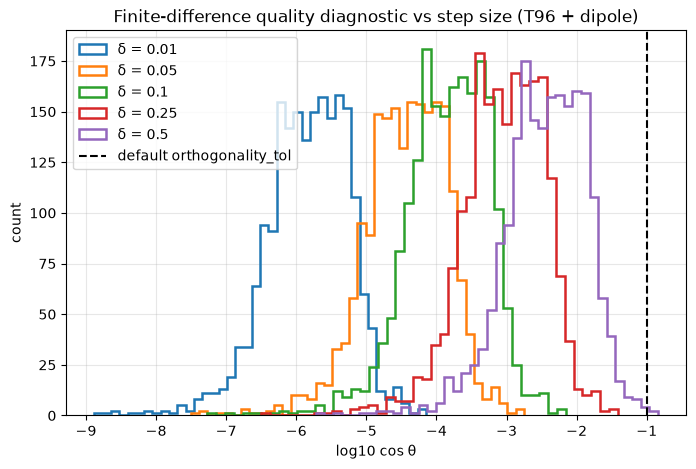

In [6]:
# A uniform field has straight field lines: curvature 0, normal undefined.
uniform = lambda x, y, z: (np.zeros_like(x), np.zeros_like(x), np.ones_like(x))
print("uniform field: kappa =", field_line_curvature(uniform, 0.0, 0.0, 0.0),
      " normal =", field_line_frenet_frame(uniform, 0.0, 0.0, 0.0)[3:6])

# A linear X-type null B = (x, -y, 0): the tangent is undefined at the origin.
xnull = lambda x, y, z: (x, -y, np.zeros_like(z))
print("X-null at origin: tangent =", field_line_frenet_frame(xnull, 0.0, 0.0, 0.0)[0:3])

# cos(theta) on random magnetospheric points, for several delta
rng = np.random.default_rng(0)
n = 2000
r = rng.uniform(2.5, 10, n); th = rng.uniform(0.3, np.pi - 0.3, n); ph = rng.uniform(0, 2 * np.pi, n)
xr, yr, zr = r * np.sin(th) * np.cos(ph), r * np.sin(th) * np.sin(ph), r * np.cos(th)

deltas = [0.01, 0.05, 0.1, 0.25, 0.5]
fig, ax = plt.subplots(figsize=(8, 5))
for dl in deltas:
    q = field_line_frame_quality(field, xr, yr, zr, delta=dl)
    q = q[np.isfinite(q)]
    ax.hist(np.log10(q), bins=40, histtype="step", lw=1.8, label=f"δ = {dl}")
    print(f"delta={dl:<5}  median cos(theta) = {np.median(q):.1e}   max = {q.max():.1e}   "
          f"fraction > tol(0.1): {np.mean(q > 0.1):.3f}")
ax.axvline(np.log10(0.1), color="k", ls="--", label="default orthogonality_tol")
ax.set_xlabel("log10 cos θ"); ax.set_ylabel("count"); ax.legend(); ax.grid(alpha=0.3)
ax.set_title("Finite-difference quality diagnostic vs step size (T96 + dipole)")
plt.show()

The distributions shift by two decades per decade of δ (the δ² scaling). Even δ = 0.5 Re stays below the default tolerance almost everywhere in this model field; you can tighten `orthogonality_tol` if you want stricter masking, or pass `np.inf` to disable it.

<a id="delta"></a>
## 6. Choosing the step size δ

Two error sources compete: truncation error (∝ δ²) and round-off in the difference quotient (∝ ε/δ). For smooth model fields the optimum is broad, around 10⁻³–10⁻² Re. The check below uses the pure dipole, whose equatorial curvature is exactly 3/r (points on the GSM y-axis lie in the magnetic equator for any tilt), together with the antisymmetry residuals of the T96 field.

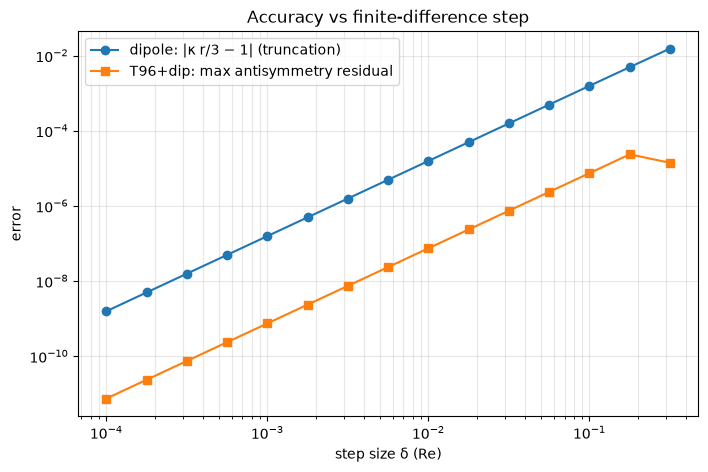

In [7]:
step_sizes = np.logspace(-4, -0.5, 15)
y_eq = np.array([4.0, 6.0, 8.0])
zero = np.zeros_like(y_eq)
kappa_err, antisym_err = [], []
for dl in step_sizes:
    k = field_line_curvature(dipole, zero, y_eq, zero, delta=dl)
    kappa_err.append(np.max(np.abs(k * y_eq / 3.0 - 1.0)))
    dd = field_line_directional_derivatives(field, np.array([-5.0, -7.0]), np.zeros(2), np.array([0.5, 1.0]), delta=dl)
    antisym_err.append(max(np.nanmax(np.abs(e)) for e in verify_antisymmetry_relations(dd).values()))

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(step_sizes, kappa_err, "o-", label="dipole: |κ r/3 − 1| (truncation)")
ax.loglog(step_sizes, antisym_err, "s-", label="T96+dip: max antisymmetry residual")
ax.set_xlabel("step size δ (Re)"); ax.set_ylabel("error"); ax.grid(alpha=0.3, which="both"); ax.legend()
ax.set_title("Accuracy vs finite-difference step")
plt.show()

<a id="trace"></a>
## 7. Geometry along a traced field line

`trace_field_lines` integrates field lines through the same callable (`direction='both'` follows the line in both senses from the seed and returns one joined path with the seed at `start_index`). The traced points feed straight back into the geometry functions, giving κ(s) and τ(s) along the line.

FieldLineTrace(n_lines=3, max_points=349, status={'inner': 3})


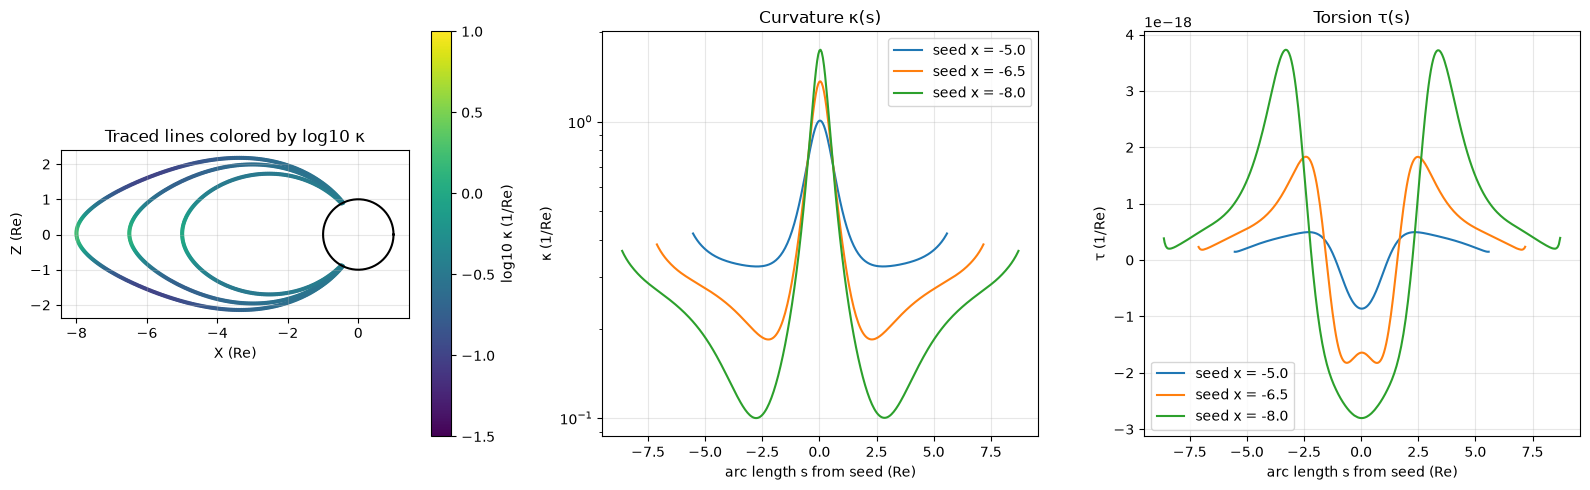

In [8]:
seeds_x = np.array([-5.0, -6.5, -8.0])
tr = trace_field_lines(field, seeds_x, np.zeros(3), np.zeros(3), direction="both", ds=0.05, r0=1.0, rlim=30.0)
print(tr)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
ax = axes[0]
for i in range(tr.n_lines):
    x, y, z = tr.path(i)
    k = field_line_curvature(field, x, y, z, delta=0.01)
    sc = ax.scatter(x, z, c=np.log10(k), s=4, cmap="viridis", vmin=-1.5, vmax=1)
th = np.linspace(0, 2 * np.pi, 200)
ax.plot(np.cos(th), np.sin(th), "k")
ax.set_aspect("equal"); ax.set_xlabel("X (Re)"); ax.set_ylabel("Z (Re)"); ax.grid(alpha=0.3)
ax.set_title("Traced lines colored by log10 κ")
plt.colorbar(sc, ax=ax, label="log10 κ (1/Re)")

for i in range(tr.n_lines):
    x, y, z = tr.path(i)
    s = tr.arc_length(i)
    k = field_line_curvature(field, x, y, z, delta=0.01)
    t = field_line_torsion(field, x, y, z, delta=0.01)
    axes[1].plot(s, k, lw=1.5, label=f"seed x = {seeds_x[i]}")
    axes[2].plot(s, t, lw=1.5, label=f"seed x = {seeds_x[i]}")
axes[1].set_yscale("log"); axes[1].set_title("Curvature κ(s)"); axes[1].set_ylabel("κ (1/Re)")
axes[2].set_title("Torsion τ(s)"); axes[2].set_ylabel("τ (1/Re)")
for ax in axes[1:]:
    ax.set_xlabel("arc length s from seed (Re)"); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
plt.show()

<a id="performance"></a>
## 8. Vectorization: looped vs batched evaluation

All functions broadcast over arrays of points; the whole computation is a fixed number of field evaluations regardless of the number of points (three per frame, 21 for the nine derivatives). Calling them in a Python loop over points is the slow path.

In [9]:
def bench(n_points, delta=0.01, seed=0):
    rng = np.random.default_rng(seed)
    x = rng.uniform(-10, -3, n_points); y = rng.uniform(-3, 3, n_points); z = rng.uniform(-2, 2, n_points)
    t0 = time.perf_counter()
    looped = [field_line_directional_derivatives(field, x[i], y[i], z[i], delta=delta)["dT_dT_n"] for i in range(n_points)]
    t_loop = time.perf_counter() - t0
    t0 = time.perf_counter()
    batched = field_line_directional_derivatives(field, x, y, z, delta=delta)["dT_dT_n"]
    t_vec = time.perf_counter() - t0
    assert np.allclose(looped, batched, rtol=1e-10, atol=1e-12)
    return t_loop, t_vec

print(f"{'points':>8} {'looped (s)':>12} {'batched (s)':>12} {'speedup':>9}")
for n in (10, 100, 300):
    tl, tv = bench(n)
    print(f"{n:>8} {tl:>12.3f} {tv:>12.3f} {tl / tv:>8.0f}x")

  points   looped (s)  batched (s)   speedup


      10        1.025        0.104       10x


     100       10.561        0.111       95x


     300       31.341        0.152      206x


<a id="maps"></a>
## 9. Maps in the noon-midnight meridian

Evaluating on a grid of points gives 2D maps. Curvature and the normal curvature (∂T/∂n)·n in the X-Z plane, with field direction arrows; NaN (undefined) cells are simply left blank by matplotlib.

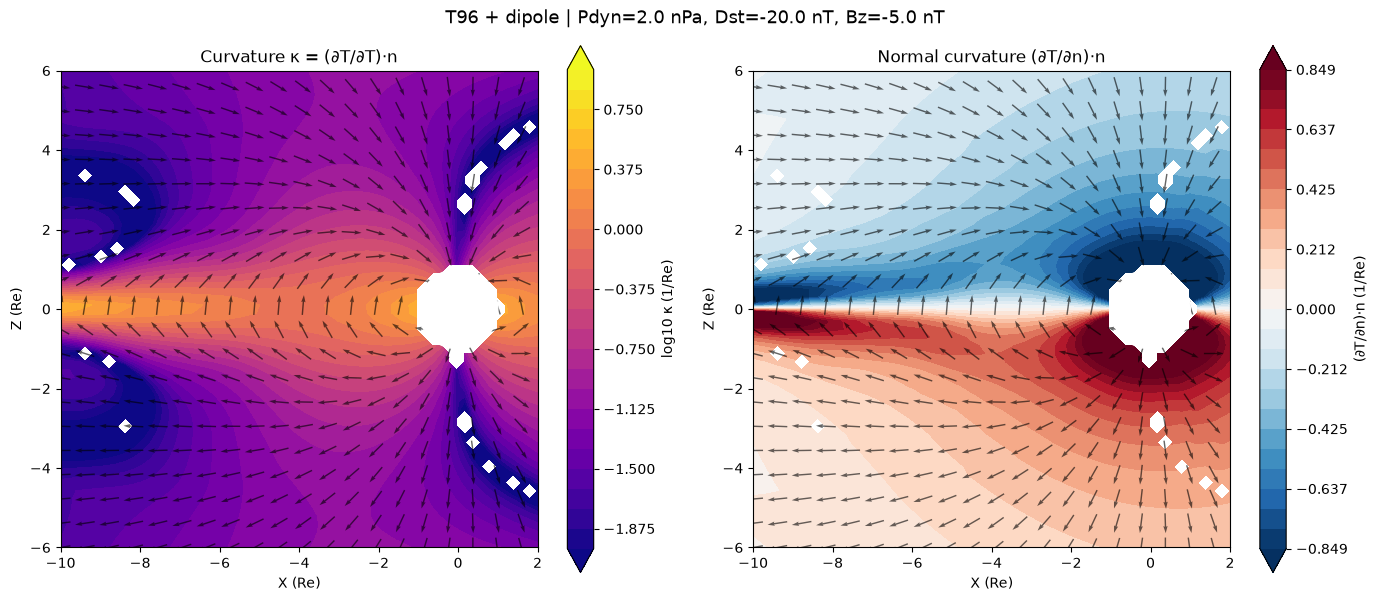

In [10]:
xg = np.linspace(-10, 2, 60); zg = np.linspace(-6, 6, 60)
X, Z = np.meshgrid(xg, zg); Y = np.zeros_like(X)
d_grid = field_line_directional_derivatives(field, X.ravel(), Y.ravel(), Z.ravel(), delta=0.01)
kappa_grid = d_grid["dT_dT_n"].reshape(X.shape)
dTdn_grid = d_grid["dT_dn_n"].reshape(X.shape)
inside = np.hypot(X, Z) < 1.0
kappa_grid[inside] = np.nan; dTdn_grid[inside] = np.nan

Bx, By, Bz = field(X, Y, Z)
Bin = np.hypot(Bx, Bz); Bin[Bin == 0] = np.nan
st = 3
qx, qz = (0.5 * Bx / Bin)[::st, ::st], (0.5 * Bz / Bin)[::st, ::st]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
c1 = axes[0].contourf(X, Z, np.log10(kappa_grid), levels=np.linspace(-2, 1, 25), cmap="plasma", extend="both")
plt.colorbar(c1, ax=axes[0], label="log10 κ (1/Re)")
axes[0].set_title("Curvature κ = (∂T/∂T)·n")
vmax = np.nanpercentile(np.abs(dTdn_grid), 95)
c2 = axes[1].contourf(X, Z, dTdn_grid, levels=np.linspace(-vmax, vmax, 25), cmap="RdBu_r", extend="both")
plt.colorbar(c2, ax=axes[1], label="(∂T/∂n)·n (1/Re)")
axes[1].set_title("Normal curvature (∂T/∂n)·n")
for ax in axes:
    ax.quiver(X[::st, ::st], Z[::st, ::st], qx, qz, angles="xy", scale_units="xy", scale=1, pivot="middle",
              color="k", alpha=0.6, width=0.003)
    ax.add_patch(plt.Circle((0, 0), 1, color="white", zorder=10))
    ax.set_aspect("equal"); ax.set_xlabel("X (Re)"); ax.set_ylabel("Z (Re)")
plt.suptitle(f"T96 + dipole | Pdyn={parmod[0]} nPa, Dst={parmod[1]} nT, Bz={parmod[3]} nT", fontsize=13)
plt.tight_layout()
plt.show()

<a id="limitations"></a>
## 10. Limitations and best practices

- **Finite differences.** Everything is a central difference with step δ; the truncation error scales as δ². The default δ = 0.01 Re is appropriate for smooth model fields. For interpolated simulation data use δ of about one grid cell (linear interpolation has a piecewise-constant derivative; see notebook 08).
- **Undefined frames are NaN.** Straight lines (κ = 0), magnetic nulls, and unresolved curvature (cos θ > `orthogonality_tol`) give NaN normals, binormals, torsion, and directional derivatives; mask with `np.isfinite`. Curvature itself is returned wherever the tangents are defined.
- **Flipping normals.** The directional derivatives along **n** and **b** difference the frame at r ± δ**n**, r ± δ**b**; across an inflection the principal normal flips and the difference quotient is meaningless. Those points are NaN as well (`normal_flip_tol`, default 0.9 for n(+δ)·n(−δ)).
- **Quality control.** `field_line_frame_quality` (cos θ) and `verify_antisymmetry_relations` are cheap checks of whether δ resolves the local geometry.
- **Units.** Positions in the field's length unit, results in its inverse — Re here, grid units for simulation data.